#Assignment2: Customizing_LoRA

<h4><div style="text-align: right"> Due date: 23:59 May 15, 2026.  </div> <br>
<div style="text-align: right"> Please upload your files and PDF report at PLATO in the form of [Name]_[Student ID].ipynb. </div></h4>



<h2><span style="color:blue">[202255597] [장건호]</span> </h2>

In [1]:
import datetime
print("This code is written at " + str(datetime.datetime.now()))

This code is written at 2026-05-15 09:06:03.145981


### **Required Package**:
- accelerate version: 0.26.1
- datasets==2.16.1
- diffusers version: 0.26.0.dev0
- invisible-watermark version: 0.2.0
- numpy version: 1.26.3
- omegaconf version: 2.3.0
- opencv-python version: 4.9.0.80
- peft==0.7.1
- scipy version: 1.12.0
- torch version: 2.1.2
- torchvision version: 0.16.2
- transformers version: 4.37.0

### **Reference**
- Diffusers Official Document  [homepage](https://huggingface.co/docs/diffusers/main/en/index)  
- Datasets Official Document  [homepage](https://huggingface.co/docs/datasets/index)
- segmind blog [blog](https://blog.segmind.com/prompt-guide-for-stable-diffusion-xl-crafting-textual-descriptions-for-image-generation/)

### **필요 패키지 import**

In [2]:
# ! pip install -q -U \
#     datasets \
#     peft \
#     diffusers \
#     bing-image-downloader

In [3]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [4]:
# Standard library imports
import gc
import math
import random
import re

# Third-party imports
import numpy as np
import pandas
import glob
import torch
import accelerate
import torch.nn.functional as F
import torch.utils.checkpoint
from PIL import Image
from accelerate import Accelerator
from accelerate.logging import get_logger
from datasets import load_dataset
from bing_image_downloader import downloader
from icrawler.builtin import BingImageCrawler
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from tqdm.auto import tqdm
from torchvision import transforms
from transformers import (
    AutoTokenizer,
    PretrainedConfig,
)

from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    StableDiffusionXLPipeline,
    UNet2DConditionModel,
    StableVideoDiffusionPipeline,
    StableDiffusionPipeline
)
from diffusers.loaders import LoraLoaderMixin
from diffusers.optimization import get_scheduler
from diffusers.training_utils import cast_training_params
from diffusers.utils import (
    make_image_grid,
    convert_state_dict_to_diffusers,
    export_to_video,
    export_to_gif,
)
from diffusers.utils.torch_utils import is_compiled_module

/home/GenAI_202255597/miniconda3/envs/genai-assignment2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Custom Dataset 정의

StableDiffusion과 같은 diffusers에서 지원하는 Diffusion 모델들은 Huggingface에서 지원하는 accelerate, datasets, transformers 와 같은 패키지들과 호환되도록 구현됨.
LoRA 학습을 위해서는 Huggingface에서 지원하는 datasets 패키지를 이용하여 Custom Dataset을 정의해야 함.


## 1-1. Folder 구조 만들기

In [5]:
custom_dataset_folder_name = "data/web_crawled_custom_dataset"
if not os.path.exists(custom_dataset_folder_name):
    os.makedirs(custom_dataset_folder_name)
if not os.path.exists(os.path.join(custom_dataset_folder_name, "train")):
    os.makedirs(os.path.join(custom_dataset_folder_name, "train"))
custom_dataset_folder_path = os.path.join(os.getcwd(), custom_dataset_folder_name)

폴더의 구조는 다음과 같이 구성되어 있어야 함.
    
    folder/train/dog/golden_retriever.png
    folder/train/cat/maine_coon.png
    folder/test/dog/german_shepherd.png
    folder/test/cat/bengal.png

## 1-2. bing 에서 open license image들 크롤링

In [6]:
# bing_image_downloader는 오래된 라이브러리이므로 제대로된 image를 크롤링 불가
# 따라서 icrawler 라이브러리를 사용하여 크롤링 진행

train_dir = os.path.join(custom_dataset_folder_path, "train")
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
existing_images = [
    path for path in glob.glob(os.path.join(train_dir, "*"))
    if os.path.splitext(path)[1].lower() in image_extensions
]

if existing_images:
    print(f"Found {len(existing_images)} existing images in {train_dir}; skipping crawler.")
else:
    crawler = BingImageCrawler(storage={"root_dir": train_dir})
    crawler.crawl(keyword="8 bit pixel art", max_num=50)


Found 50 existing images in /home/GenAI_202255597/workspace/project/Customizing_LoRA/data/web_crawled_custom_dataset/train; skipping crawler.


In [7]:
# # 파일 이름 변경
# for idx, item in enumerate(
#     os.listdir(
#         os.path.join(
#             custom_dataset_folder_path,
#             query,
#         )
#     )
# ):
#     format = item.split(".")[-1]
#     # idx format 0 -> 00
#     idx = str(idx).zfill(2)
#     os.rename(
#         os.path.join(custom_dataset_folder_path, query, item),
#         os.path.join(custom_dataset_folder_path, "train", f"{idx}.{format}"),
#     )

# 1-3. Captioning

이미지와 함께 이미지에 대한 설명을 캡셔닝 모델 BLIP을 사용하여 생성

In [8]:
# Device 정의
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from transformers import BlipProcessor, BlipForConditionalGeneration
# 모델은 "Salesforce/blip-image-captioning-base"로 processor는 "Salesforce/blip-image-captioning-large"로 초기화
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)

Using device: cuda


In [9]:
# STYLE LoRA를 추가하기 위한 토큰과 단어 리스트 정의
STYLE_TOKEN = "sks"
STYLE_WORDS = sorted([
    "pixel art", "pixel-art", "pixelated", "pixels", "pixel",
    "8-bit", "8bit", "8 bit",
    "16-bit", "16bit",
    "retro", "sprite", "blocky", "mosaic",
    "video game", "game", "low resolution", "low-res",
], key=len, reverse=True)  

In [10]:
image_paths = sorted(
    path for path in glob.glob(os.path.join(custom_dataset_folder_path, "train", "*"))
    if os.path.splitext(path)[1].lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
)
test_image = Image.open(image_paths[0]).convert("RGB")

# conditional captioning: "a photo of" 프롬프트로 content만 추출
inputs = processor(test_image, "a photo of", return_tensors="pt").to(device)
outputs = model.generate(**inputs, max_new_tokens=75, num_beams=5)
blip_caption = processor.decode(outputs[0], skip_special_tokens=True)

# 스타일 단어 제거 후 style token 삽입
content = blip_caption.replace("a photo of", "").strip()
for word in STYLE_WORDS:
    content = re.sub(rf'\b{re.escape(word)}\b', '', content, flags=re.IGNORECASE).strip()
content = re.sub(r'\s+', ' ', content).strip()

caption = f"{STYLE_TOKEN} {content}"
print(f"BLIP raw : {blip_caption}")
print(f"학습 캡션: {caption}")

BLIP raw : a photo of a man with a beard and blue eyes
학습 캡션: sks a man with a beard and blue eyes


## 1-4. Metadata.csv 작성

pandas dataframe을 이용하여 caption을 저장하고 metadata.csv 파일을 작성


    file_name,additional_feature
    0001.png,This is a first value of a text feature you added to your images
    0002.png,This is a second value of a text feature you added to your images
    0003.png,This is a third value of a text feature you added to your images


In [11]:
metadata = pandas.DataFrame(columns=["file_name", "caption"])

In [12]:
metadata_path = os.path.join(custom_dataset_folder_path, "train", "metadata.csv")

if os.path.exists(metadata_path):
    print(f"metadata.csv already exists: {metadata_path}")
else:
    metadata = pandas.DataFrame(columns=["file_name", "caption"])

    # metadata.csv를 제외하고 이미지 파일만 순회
    image_paths = sorted(
        path for path in glob.glob(os.path.join(custom_dataset_folder_path, "train", "*"))
        if os.path.splitext(path)[1].lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    )

    for idx, image_path in enumerate(image_paths):
        item = os.path.basename(image_path)
        test_image = Image.open(image_path).convert("RGB")

        # conditional captioning으로 content 추출
        inputs = processor(test_image, "a photo of", return_tensors="pt").to(device)
        out = model.generate(**inputs, max_new_tokens=75, num_beams=5)
        blip_caption = processor.decode(out[0], skip_special_tokens=True)

        # 스타일 단어 제거 후 style token 삽입
        content = blip_caption.replace("a photo of", "").strip()
        for word in STYLE_WORDS:
            content = re.sub(rf'\b{re.escape(word)}\b', '', content, flags=re.IGNORECASE).strip()
        content = re.sub(r'\s+', ' ', content).strip()

        caption = f"{STYLE_TOKEN} {content}"
        metadata.loc[idx] = [item, caption]

    metadata = metadata.sort_values(by=["file_name"]).reset_index(drop=True)
    metadata.to_csv(metadata_path, index=False)
    print(f"Saved metadata.csv: {metadata_path}")

metadata.csv already exists: /home/GenAI_202255597/workspace/project/Customizing_LoRA/data/web_crawled_custom_dataset/train/metadata.csv


최종 폴더구조
<pre><code>
├── gen_ai_custom_dataset
│   └── train
│   │    └── metadata.csv
│   │    └── 00.jpg
...
</code></pre>

## 1-5. Customdataset 정의

In [13]:
custom_dataset = load_dataset("imagefolder", data_dir=custom_dataset_folder_path)

Resolving data files: 100%|██████████| 51/51 [00:00<00:00, 253447.28it/s]


## 2. LoRA 학습

#### Prompt Tokenization 을 위한 함수 선언

In [14]:
def tokenize_prompt(tokenizer, prompt):
    text_inputs = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
)
    text_input_ids = text_inputs.input_ids
    return text_input_ids


def encode_prompt(text_encoders, tokenizers, prompt, text_input_ids_list=None):
    prompt_embeds_list = []

    for i, text_encoder in enumerate(text_encoders):
        if tokenizers is not None:
            tokenizer = tokenizers[i]
            text_input_ids = tokenize_prompt(tokenizer, prompt)
        else:
            assert text_input_ids_list is not None
            try:
                text_input_ids = text_input_ids_list[i]
            except IndexError:
                pass

        prompt_embeds = text_encoder(
            text_input_ids.to(text_encoder.device),
            output_hidden_states=True,
            return_dict=False,
    )

        pooled_prompt_embeds = prompt_embeds[0]
        prompt_embeds = prompt_embeds[-1][-2]
        bs_embed, seq_len, _ = prompt_embeds.shape
        prompt_embeds = prompt_embeds.view(bs_embed, seq_len, -1)
        prompt_embeds_list.append(prompt_embeds)

    prompt_embeds = torch.concat(prompt_embeds_list, dim=-1)
    pooled_prompt_embeds = pooled_prompt_embeds.view(bs_embed, -1)
    return prompt_embeds, pooled_prompt_embeds

def import_model_class_from_model_name_or_path(
    pretrained_model_name_or_path: str, subfolder: str = "text_encoder"
):
    text_encoder_config = PretrainedConfig.from_pretrained(
        pretrained_model_name_or_path, subfolder=subfolder
)
    model_class = text_encoder_config.architectures[0]

    if model_class == "CLIPTextModel":
        from transformers import CLIPTextModel

        return CLIPTextModel(text_encoder_config).from_pretrained(
            pretrained_model_name_or_path, subfolder=subfolder
        )
    elif model_class == "CLIPTextModelWithProjection":
        from transformers import CLIPTextModelWithProjection

        return CLIPTextModelWithProjection(text_encoder_config).from_pretrained(
            pretrained_model_name_or_path, subfolder=subfolder
        )
    else:
        raise ValueError(f"{model_class} is not supported.")

### StableDiffusion을 구성하는 세부 모델들 선언

#### Pretrained Model 및 기타 config 선언
학습에 사용될 pretrained model은 "runwayml/stable-diffusion-v1-5" 을 이용
빠른 학습을 위해 Floating Point Precision (부동소수점) 은 16 FP16 을 사용

In [15]:
MODEL_NAME  = "runwayml/stable-diffusion-v1-5"
VAE_NAME ="stabilityai/sd-vae-ft-mse"
VARIANT = "fp16"

#### Tokenizer, Text Encoder 선언

In [16]:
tokenizer_one = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        subfolder="tokenizer",
        use_fast=True,
)
text_encoder_one = import_model_class_from_model_name_or_path(
        MODEL_NAME,
        subfolder="text_encoder",
)

tokenize_two, text_encoder_two = None, None

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


#### Noise Scheduler, VAE, UNET 선언


In [17]:
noise_scheduler = DDPMScheduler.from_pretrained(
        MODEL_NAME,
        subfolder="scheduler",
)

vae = AutoencoderKL.from_pretrained(
        VAE_NAME
)

unet = UNet2DConditionModel.from_pretrained(
        MODEL_NAME,
        subfolder="unet",
        variant=VARIANT,
)

Freezing VAE, UNET, text encoder

선언한 네트워크의 파라미터들은 학습 과정에서 업데이트가 되지 않아야 하므로 requires_grad를 False로 설정

In [18]:
vae.requires_grad_(False)
text_encoder_one.requires_grad_(False)
unet.requires_grad_(False)

vae.eval()
text_encoder_one.eval()

print("VAE, Text Encoder, and UNet are frozen.")

VAE, Text Encoder, and UNet are frozen.


### 학습 루프 함수 정의
- 학습 Step 수는 10,000 Step을 권장하나, 학습 소요 시간이 오래 걸릴 경우, Step 수를 줄여 학습을 진행

In [19]:
seed = 2015
train_batch_size = 8
resolution = 512
max_train_steps = 2000
checkpointing_steps = 500
learning_rate = 1e-4
output_dir = "./sd_lora"

# Make sure output_dir exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Ablation study on LoRA configuration

1. Dimension of LoRA update Matrices (lora_rank)

2. LoRA scaling factor



In [20]:
logger = get_logger(__name__)

def training_function(
    dataset,
    unet,
    vae,
    text_encoder_one,
    text_encoder_two=None,
    lora_rank=4,
    lora_alpha=4,
    run_output_dir=None,
    run_max_train_steps=None,
):

    current_output_dir = run_output_dir or output_dir
    current_max_train_steps = run_max_train_steps or max_train_steps
    os.makedirs(current_output_dir, exist_ok=True)

    # Init Accelerator
    accelerator = Accelerator(mixed_precision=VARIANT)
    weight_dtype = torch.float32
    if accelerator.mixed_precision == "fp16":
        weight_dtype = torch.float16
    elif accelerator.mixed_precision == "bf16":
        weight_dtype = torch.bfloat16

    # 세부 모델들 GPU로 올리기, 및 datatype 설정
    unet.to(accelerator.device, dtype=weight_dtype)
    vae.to(accelerator.device, dtype=weight_dtype)
    text_encoder_one.to(accelerator.device, dtype=weight_dtype)
    if text_encoder_two is not None:
        text_encoder_two.to(accelerator.device, dtype=weight_dtype)

    # LoRA config 설정
    # UNet의 Attention Layer에 LoRA weights를 추가
    # Set correct lora layers
    unet_lora_config = LoraConfig(
        r=lora_rank, 
        lora_alpha=lora_alpha,
        init_lora_weights="gaussian",
        target_modules=["to_k", "to_q", "to_v", "to_out.0"],
    )
    unet.add_adapter(unet_lora_config)

    # Trainable Parameter (LoRA weights) 만을 FP32로 Upcast
    cast_training_params([unet], dtype=torch.float32)

    # Accelerator에 wrap된 모델을 unwrap하는 내부함수
    def unwrap_model(model):
        model = accelerator.unwrap_model(model)
        model = model._orig_mod if is_compiled_module(model) else model
        return model


    # Custom 된  save & loading hook 함수. LoRA Weight만을 저장하고 불러오는 용도로 사용
    # 실질적으로 accelrator.save_state() 함수 사용을 위해 필요한 함수
    def save_model_hook(models, weights, output_dir):
        if accelerator.is_main_process:
            # there are only two options here. Either are just the unet attn processor layers
            # or there are the unet and text encoder atten layers
            unet_lora_layers_to_save = None
            text_encoder_one_lora_layers_to_save = None
            if text_encoder_two is not None:
                text_encoder_two_lora_layers_to_save = None

            for model in models:
                if isinstance(unwrap_model(model), type(unwrap_model(unet))):
                    unet_lora_layers_to_save = convert_state_dict_to_diffusers(
                        get_peft_model_state_dict(model)
                    )
                elif isinstance(
                    unwrap_model(model), type(unwrap_model(text_encoder_one))
                ):
                    text_encoder_one_lora_layers_to_save = (
                        convert_state_dict_to_diffusers(
                            get_peft_model_state_dict(model)
                        )
                    )
                elif isinstance(
                    unwrap_model(model), type(unwrap_model(text_encoder_two))
                ):
                    text_encoder_two_lora_layers_to_save = (
                        convert_state_dict_to_diffusers(
                            get_peft_model_state_dict(model)
                        )
                    )
                else:
                    raise ValueError(f"unexpected save model: {model.__class__}")

                # make sure to pop weight so that corresponding model is not saved again
                if weights:
                    weights.pop()

            if text_encoder_two is not None:
                StableDiffusionXLPipeline.save_lora_weights(
                    output_dir,
                    unet_lora_layers=unet_lora_layers_to_save,
                    text_encoder_lora_layers=text_encoder_one_lora_layers_to_save,
                    text_encoder_2_lora_layers=text_encoder_two_lora_layers_to_save,
                )
            else:
                StableDiffusionPipeline.save_lora_weights(
                    output_dir,
                    unet_lora_layers=unet_lora_layers_to_save,
                    text_encoder_lora_layers=text_encoder_one_lora_layers_to_save,
                )

    def load_model_hook(models, input_dir):
        unet_ = None
        text_encoder_one_ = None
        text_encoder_two_ = None

        while len(models) > 0:
            model = models.pop()

            if isinstance(model, type(unwrap_model(unet))):
                unet_ = model
            elif isinstance(model, type(unwrap_model(text_encoder_one))):
                text_encoder_one_ = model
            elif isinstance(model, type(unwrap_model(text_encoder_two))):
                text_encoder_two_ = model
            else:
                raise ValueError(f"unexpected save model: {model.__class__}")

        lora_state_dict, network_alphas = LoraLoaderMixin.lora_state_dict(input_dir)
        LoraLoaderMixin.load_lora_into_unet(
            lora_state_dict, network_alphas=network_alphas, unet=unet_
        )

        text_encoder_state_dict = {
            k: v for k, v in lora_state_dict.items() if "text_encoder." in k
        }
        LoraLoaderMixin.load_lora_into_text_encoder(
            text_encoder_state_dict,
            network_alphas=network_alphas,
            text_encoder=text_encoder_one_,
        )
        if text_encoder_two_ is not None:
            text_encoder_2_state_dict = {
                k: v for k, v in lora_state_dict.items() if "text_encoder_2." in k
            }
            LoraLoaderMixin.load_lora_into_text_encoder(
                text_encoder_2_state_dict,
                network_alphas = network_alphas,
                text_encoder = text_encoder_two_,
            )

    accelerator.register_save_state_pre_hook(save_model_hook)
    accelerator.register_load_state_pre_hook(load_model_hook)

    # Optimizer 설정
    optimizer_class = torch.optim.AdamW
    # Optimizer creation
    params_to_optimize = list(filter(lambda p: p.requires_grad, unet.parameters()))
    optimizer = optimizer_class(
        params_to_optimize,
        # lr=learning_rate*train_batch_size,
        lr=learning_rate,
        betas = (0.9, 0.999),
        weight_decay = 1e-2,
        eps = 1e-08,
    )

    # Preprocessing the datasets
    # 먼저 데이터셋의 Column 구분 (Image, Caption)
    column_names = dataset["train"].column_names
    image_column = column_names[0]
    caption_column = column_names[1]

   # Captipon 들을 두가지 Text Tokenizer로 Tokenize 하는 내부함수 정의
    def tokenize_captions(examples, is_train=True,):
        captions = []
        for caption in examples[caption_column]:
            if isinstance(caption, str):
                captions.append(caption)
            elif isinstance(caption, (list, np.ndarray)):
                # take a random caption if there are multiple
                captions.append(random.choice(caption) if is_train else caption[0])
            else:
                raise ValueError(
                    f"Caption column `{caption_column}` should contain either strings or lists of strings."
                )
        tokens_one = tokenize_prompt(tokenizer_one, captions)
        if text_encoder_two is not None:
            tokens_two = tokenize_prompt(tokenizer_two, captions)
        else:
            tokens_two = None
        return tokens_one, tokens_two

    # Image 를 전처리 하는 부분 정의
    train_resize = transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR)
    train_crop = transforms.CenterCrop(resolution)
    train_flip = transforms.RandomHorizontalFlip(p=1.0)
    train_transforms = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
    )

    # Image 와 Caption preprocessing 을 위한 종합 내부함수정의
    def preprocess_train(examples):
        images = [image.convert("RGB") for image in examples[image_column]]
        # image aug
        original_sizes = []
        all_images = []
        crop_top_lefts = []
        for image in images:
            original_sizes.append((image.height, image.width))
            image = train_resize(image)
            if random.random() < 0.5:# flip
                image = train_flip(image)
            y1 = max(0, int(round((image.height - resolution) / 2.0)))
            x1 = max(0, int(round((image.width - resolution) / 2.0)))
            image = train_crop(image)
            crop_top_left = (y1, x1)
            crop_top_lefts.append(crop_top_left)
            image = train_transforms(image)
            all_images.append(image)

        examples["original_sizes"] = original_sizes
        examples["crop_top_lefts"] = crop_top_lefts
        examples["pixel_values"] = all_images
        tokens_one, tokens_two = tokenize_captions(examples)
        examples["input_ids_one"] = tokens_one
        if text_encoder_two is not None:
            examples["input_ids_two"] = tokens_two
        return examples

    # Training Dataset 생성
    train_dataset = dataset["train"].with_transform(preprocess_train)

    # DataLoader 생성
    def collate_fn(examples):
        pixel_values = torch.stack([example["pixel_values"] for example in examples])
        pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
        original_sizes = [example["original_sizes"] for example in examples]
        crop_top_lefts = [example["crop_top_lefts"] for example in examples]
        input_ids_one = torch.stack([example["input_ids_one"] for example in examples])
        if text_encoder_two is not None:
            input_ids_two = torch.stack([example["input_ids_two"] for example in examples])
            return {
                "pixel_values": pixel_values,
                "input_ids_one": input_ids_one,
                "input_ids_two": input_ids_two,
                "original_sizes": original_sizes,
                "crop_top_lefts": crop_top_lefts,
            }
        else:
            return {
                "pixel_values": pixel_values,
                "input_ids_one": input_ids_one,
                "original_sizes": original_sizes,
                "crop_top_lefts": crop_top_lefts,
            }
    train_dataloader = torch.utils.data.DataLoader(
        train_dataset,
        shuffle = True,
        collate_fn = collate_fn,
        batch_size = train_batch_size,
        num_workers = 0,
    )

    lr_scheduler = get_scheduler(
        'cosine',
        optimizer=optimizer,
        num_warmup_steps = current_max_train_steps * 0.1 * 1, # warmup step은 전체 step의 10%로 설정.
        num_training_steps = current_max_train_steps * 1,
    )

    # Prepare with  accelerator
    unet, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(unet, optimizer, train_dataloader, lr_scheduler)


    # Training 시작 전 기본 세팅
    num_train_epochs = math.ceil(current_max_train_steps / len(train_dataloader))
    total_batch_size = train_batch_size * accelerator.num_processes
    logger.info("***** Running training *****")
    logger.info(f"  Num examples = {len(train_dataset)}")
    logger.info(f"  Num Epochs = {num_train_epochs}")
    logger.info(f"  Instantaneous batch size per device = {train_batch_size}")
    logger.info(f"  Total train batch size (w. parallel, distributed & accumulation) = {total_batch_size}")
    logger.info(f"  Total optimization steps = {current_max_train_steps}")
    resume_from_checkpoint = os.path.join(current_output_dir, "checkpoint-1500")
    if not os.path.isdir(resume_from_checkpoint):
        resume_from_checkpoint = None

    global_step = 0
    first_epoch = 0
    resume_step = 0

    if resume_from_checkpoint is not None:
        accelerator.load_state(resume_from_checkpoint)
        cast_training_params([unet], dtype=torch.float32)

        base_optimizer = optimizer.optimizer if hasattr(optimizer, "optimizer") else optimizer
        for group in base_optimizer.param_groups:
            for param in group["params"]:
                state = base_optimizer.state.get(param, {})
                for key, value in state.items():
                    if torch.is_tensor(value):
                        if key == "step":
                            state[key] = value.to(device=param.device, dtype=torch.float32)
                        else:
                            state[key] = value.to(device=param.device, dtype=param.dtype)

        checkpoint_name = os.path.basename(resume_from_checkpoint)
        global_step = int(checkpoint_name.split("-")[-1])

        if accelerator.is_main_process:
            loss_log_path = os.path.join(current_output_dir, "loss_log.csv")
            if os.path.exists(loss_log_path):
                loss_log = pandas.read_csv(loss_log_path)
                loss_log = loss_log[loss_log["step"] <= global_step]
                loss_log.to_csv(loss_log_path, index=False)

        first_epoch = global_step // len(train_dataloader)
        resume_step = global_step % len(train_dataloader)

        print(f"Resumed from {resume_from_checkpoint} at step {global_step}")

    progress_bar = tqdm(
        range(0, current_max_train_steps),
        initial = global_step,
        desc="Steps",
        # Only show the progress bar once on each machine.
        disable = not accelerator.is_local_main_process,
    )

    # Training Loop 시작
    for epoch in range(first_epoch, num_train_epochs):
        unet.train()
        train_loss = 0.0
        for step, batch in enumerate(train_dataloader):
            if resume_from_checkpoint is not None and epoch == first_epoch and step < resume_step:
                continue

            with accelerator.accumulate(unet):
                # Convert images to latent space
                pixel_values = batch["pixel_values"].to(dtype=weight_dtype)
                model_input = vae.encode(pixel_values).latent_dist.sample()
                model_input = model_input * vae.config.scaling_factor

                # Sample noise that we'll add to the latents
                noise = torch.randn_like(model_input)

                bsz = model_input.shape[0]
                # Sample a random timestep for each image
                timesteps = torch.randint(
                    0,
                    noise_scheduler.config.num_train_timesteps,
                    (bsz,),
                    device=model_input.device,
                )
                timesteps = timesteps.long()

                # Add noise to the model input according to the noise magnitude at each timestep
                # (this is the forward diffusion process)
                noisy_model_input = noise_scheduler.add_noise(model_input, noise, timesteps)

                # time ids
                def compute_time_ids(original_size, crops_coords_top_left):
                    # Adapted from pipeline.StableDiffusionXLPipeline._get_add_time_ids
                    target_size = (resolution, resolution)
                    add_time_ids = list(original_size + crops_coords_top_left + target_size)
                    add_time_ids = torch.tensor([add_time_ids])
                    add_time_ids = add_time_ids.to(accelerator.device, dtype=weight_dtype)
                    return add_time_ids

                add_time_ids = torch.cat(
                    [
                        compute_time_ids(s, c)
                        for s, c in zip(
                            batch["original_sizes"], batch["crop_top_lefts"]
                        )
                    ]
                )

                # Predict the noise residual
                unet_added_conditions = {"time_ids": add_time_ids}

                if text_encoder_two is not None:
                    text_input_ids_list = [
                        batch["input_ids_one"],
                        batch["input_ids_two"],
                    ]
                    prompt_embeds, pooled_prompt_embeds = encode_prompt(
                        text_encoders=[text_encoder_one, text_encoder_two],
                        tokenizers=None,
                        prompt=None,
                        text_input_ids_list=text_input_ids_list,
                    )
                else:
                    text_input_ids_list = [batch["input_ids_one"]]

                    prompt_embeds, pooled_prompt_embeds = encode_prompt(
                        text_encoders=[text_encoder_one],
                        tokenizers=None,
                        prompt=None,
                        text_input_ids_list=text_input_ids_list,
                    )
                unet_added_conditions.update({"text_embeds": pooled_prompt_embeds})
                model_pred = unet(
                    noisy_model_input,
                    timesteps,
                    prompt_embeds,
                    added_cond_kwargs=unet_added_conditions,
                    return_dict=False,
                )[0]


                if noise_scheduler.config.prediction_type == "epsilon":
                    target = noise
                elif noise_scheduler.config.prediction_type == "v_prediction":
                    target = noise_scheduler.get_velocity(model_input, noise, timesteps)
                else:
                    raise ValueError(
                        f"Unknown prediction type {noise_scheduler.config.prediction_type}"
                    )

                loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")


                # Gather the losses across all processes for logging (if we use distributed training).
                avg_loss = accelerator.gather(loss.repeat(train_batch_size)).mean()
                train_loss += avg_loss.item()

                # Backpropagate
                accelerator.backward(loss)
                if accelerator.sync_gradients:
                    accelerator.clip_grad_norm_(params_to_optimize, 1)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            # Checks if the accelerator has performed an optimization step behind the scenes
            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1
                accelerator.log({"train_loss": train_loss}, step=global_step)
                train_loss = 0.0

                if accelerator.is_main_process:
                    if global_step % checkpointing_steps == 0:
                        save_path = os.path.join(
                            current_output_dir, f"checkpoint-{global_step}"
                        )
                        accelerator.save_state(save_path)
                        logger.info(f"Saved state to {save_path}")

            logs = {
                "step_loss": loss.detach().item(),
                "lr": lr_scheduler.get_last_lr()[0],
            }
            progress_bar.set_postfix(**logs)

            if accelerator.is_main_process:
                loss_log_path = os.path.join(current_output_dir, "loss_log.csv")
                with open(loss_log_path, "a") as f:
                    if global_step == 1:
                        f.write("step,step_loss,lr\n")
                    f.write(f"{global_step},{loss.detach().item():.6f},{lr_scheduler.get_last_lr()[0]:.8f}\n")


            if global_step >= current_max_train_steps:
                break
    # Training 종료
    # Save the lora layers
    accelerator.wait_for_everyone()
    if accelerator.is_main_process:
        unet = unwrap_model(unet)
        unet_lora_state_dict = convert_state_dict_to_diffusers(get_peft_model_state_dict(unet))
        StableDiffusionPipeline.save_lora_weights(
            save_directory=current_output_dir,
            unet_lora_layers=unet_lora_state_dict,
        )

    accelerator.free_memory()
    del unet, vae, text_encoder_one, optimizer, train_dataloader, lr_scheduler
    if text_encoder_two is not None:
        del text_encoder_two
    gc.collect()
    torch.cuda.empty_cache()

In [21]:
import accelerate

accelerate.notebook_launcher(
    training_function,
    args=(custom_dataset, unet, vae, text_encoder_one),
    num_processes=1,
)

Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Launching training on one GPU.


Steps: 100%|██████████| 2000/2000 [1:22:13<00:00,  2.47s/it, lr=6.85e-10, step_loss=0.192] 


## Loading pretrained LoRA

학습된 LoRA 모델을 불러와서 inference를 수행하기 위해 pipeline을 정의

In [22]:
pipeline = StableDiffusionPipeline.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    variant=VARIANT if torch.cuda.is_available() else None,
    use_safetensors=True,
    safety_checker=None,
    requires_safety_checker=False,
)
pipeline = pipeline.to(device)
print("pipeline loaded")

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  6.73it/s]


pipeline loaded


In [30]:
pipeline.load_lora_weights("./sd_lora")

100%|██████████| 50/50 [00:07<00:00,  7.11it/s]


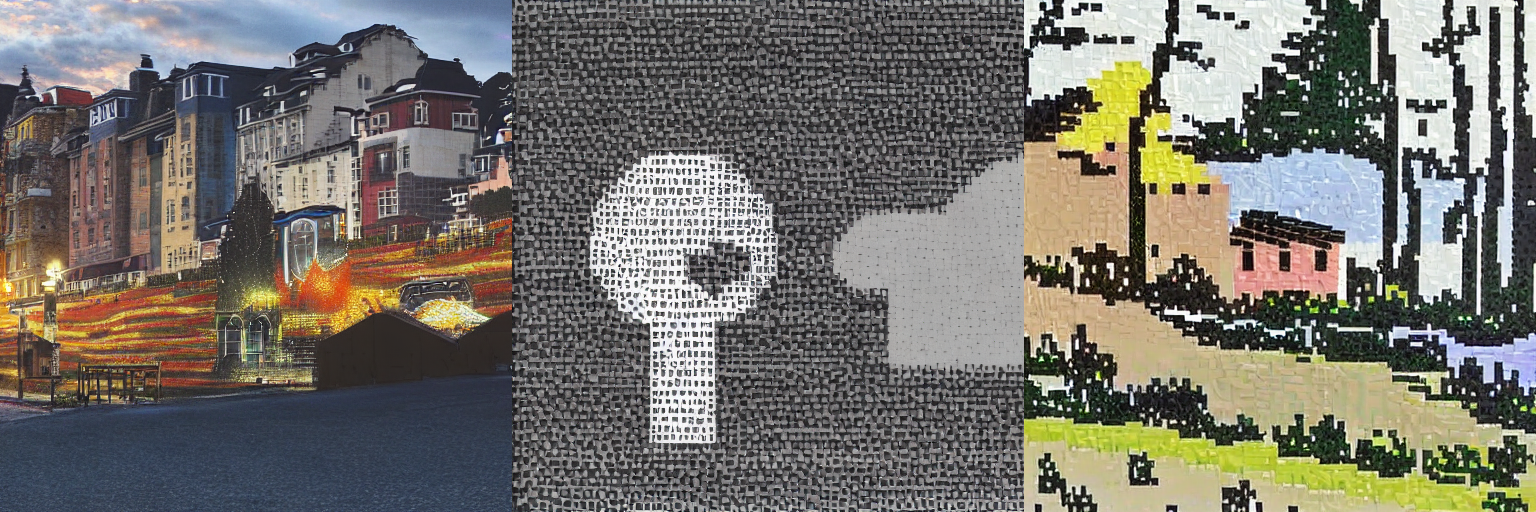

In [31]:
inference_prompt = "a city illustration"
images = pipeline(inference_prompt, num_images_per_prompt=3).images
make_image_grid(images, rows=1, cols=3)